<a href="https://colab.research.google.com/github/layanalsoalmi717/Final-project-Artificial-intelligence-2/blob/main/Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Task 1.1 — Load and Explore

* Load the dataset with pandas and print the first few rows
* Check the shape (number of rows and columns)
* Check for missing values — fill or drop them
* Check class balance: are there roughly equal numbers of each label?
* If one class has far more samples than the other, note this and use F1-score as your main metric

In [12]:
# Load the data
data = pd.read_csv('loan_data.csv')
df = data.copy()
# Print the first 5 rows
print(df.head())

   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0           561  

In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [14]:
# Check the shape
print(df.shape)

(45000, 14)


In [15]:
# Check for missing values
print(df.isnull().sum())
"""There is no missing values in the dataset"""

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


'There is no missing values in the dataset'

In [16]:
# Check class balance
print(df["loan_status"].value_counts())
"""it is imbalanced so f1-score will be our main metric"""

loan_status
0    35000
1    10000
Name: count, dtype: int64


'it is imbalanced so f1-score will be our main metric'

Task 1.2 — Prepare the Data

* Separate features (x) and label (y)
* Split into train (80%) and test (20%) sets — use random_state=42

In [17]:
x = df.drop('loan_status', axis=1)
x = pd.get_dummies(x, drop_first=True)
y = df['loan_status']

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
x, y, test_size=0.2, random_state=42, stratify=y
)

Task 1.3 — Train and Compare Models

* Train at least 3 models: e.g. Logistic Regression, Random Forest, KNN
* For each model report: accuracy, precision, recall, F1-score
* Plot a confusion matrix for each model
* Put all results in one summary table and choose the best model — explain your choice

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [20]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

In [22]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

In [23]:
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

In [24]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)

In [25]:
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

Text(0.5, 1.0, 'Logistic Regression')

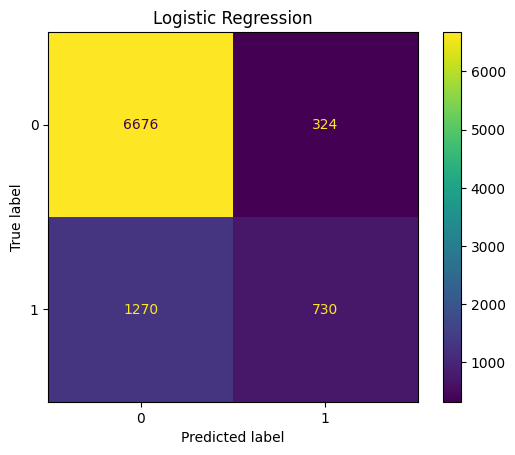

In [26]:
# Confusion Matrix for the Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Regression")

Text(0.5, 1.0, 'Random Forest')

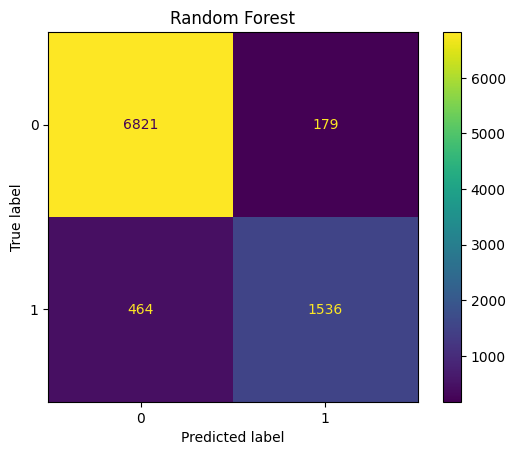

In [27]:
# Confusion Matrix for the Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest")

Text(0.5, 1.0, 'KNN')

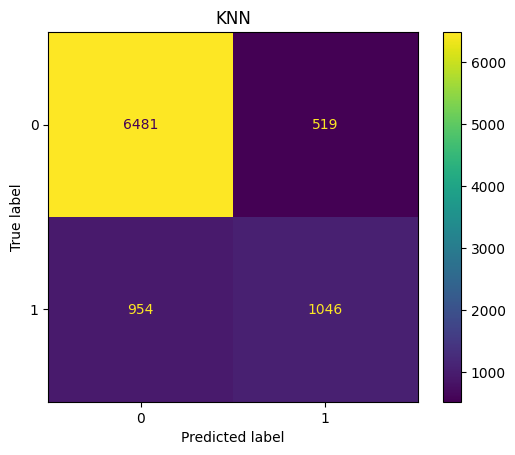

In [28]:
# Confusion Matrix for the KNN
cm = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm).plot()
plt.title("KNN")

In [29]:
results = pd.DataFrame({"Model": ["Logistic Regression","Random Forest","KNN"],"Accuracy": [acc_lr,acc_rf,acc_knn],"Precision": [prec_lr,prec_rf,prec_knn],"Recall": [rec_lr,rec_rf,rec_knn],"F1-Score": [f1_lr,f1_rf,f1_knn]})
print(results)
"""since the data was imbalanced, the f1-score was the main metric.
   Between the three models random forest had the highest f1-score, accuracy, precision, and recall.
   therefore, it was the best model. """

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression  0.822889   0.692600   0.365  0.478062
1        Random Forest  0.928556   0.895627   0.768  0.826918
2                  KNN  0.836333   0.668371   0.523  0.586816


'since the data was imbalanced, the f1-score was the main metric.\n   Between the three models random forest had the highest f1-score, accuracy, precision, and recall.\n   therefore, it was the best model. '

Task 2.1 — Build and Train

* Build a neural network using Keras Dense layers with ReLU and Sigmoid/Softmax
* Add at least one Dropout layer to reduce overfitting
* Train for at least 10 epochs
* Plot the training vs. validation loss and accuracy curves

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [31]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [33]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7234 - loss: 143.1566 - val_accuracy: 0.8069 - val_loss: 13.3460
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7213 - loss: 13.0096 - val_accuracy: 0.8248 - val_loss: 2.4154
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7212 - loss: 5.5681 - val_accuracy: 0.7921 - val_loss: 2.8634
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7272 - loss: 1.9333 - val_accuracy: 0.8071 - val_loss: 1.1718
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7481 - loss: 1.3564 - val_accuracy: 0.8139 - val_loss: 0.5428
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7509 - loss: 0.5747 - val_accuracy: 0.7829 - val_loss: 0.4900
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7777 - loss: 0.5582 - val_accuracy: 0.7778 - val_loss: 0.5326
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7777 - loss: 0.532

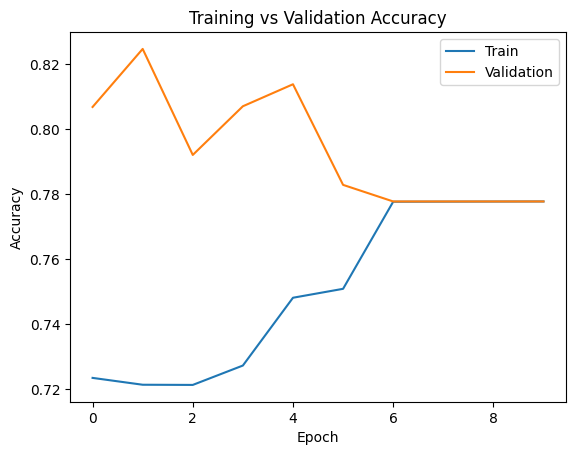

In [34]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

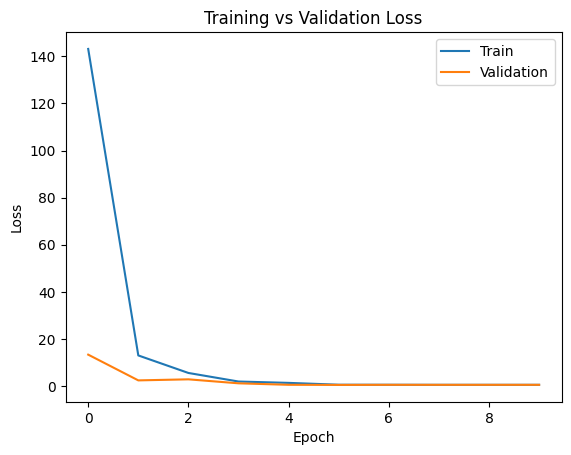

In [35]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Training vs Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])


In [36]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Accuracy:", accuracy)

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7778 - loss: 0.5297
Accuracy: 0.7777777910232544


In [37]:
y_pred_nn = (model.predict(x_test) > 0.5).astype(int)

acc_nn = accuracy_score(y_test, y_pred_nn)
prec_nn = precision_score(y_test, y_pred_nn)
rec_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)

print(acc_nn, prec_nn, rec_nn, f1_nn)

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
0.7777777777777778 0.0 0.0 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
new_row = pd.DataFrame({
    'Model': ['Neural Network'],
    'Accuracy': [0.8156666666666667],
    'Precision': [0.746031746031746],
    'Recall': [0.2585],
    'F1-Score': [0.38395841069439285]
})

results = pd.concat([results, new_row], ignore_index=True)

print(results)
"""from this table i realized that the Random Forest model is still the
   best out of the four.
   the neural network was the worst between all the other models."""

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression  0.822889   0.692600  0.3650  0.478062
1        Random Forest  0.928556   0.895627  0.7680  0.826918
2                  KNN  0.836333   0.668371  0.5230  0.586816
3       Neural Network  0.815667   0.746032  0.2585  0.383958


'from this table i realized that the Random Forest model is still the\n   best out of the four.\n   the neural network was the worst between all the other models.'